В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

### 1. Three industries where Computer Vision is widely used today

#### 1. Automotive Industry

Computer vision is a key component of modern driver-assistance systems (ADAS) and autonomous vehicles. It is used for lane detection, traffic sign recognition, pedestrian detection, obstacle avoidance, and parking assistance.

#### 2. Manufacturing and Quality Control

Factories use computer vision to automatically inspect products and detect defects during production. This helps improve product quality, reduce human error, and increase production efficiency.

#### 3. Healthcare

Computer vision assists medical professionals in analyzing medical images such as X-rays, CT scans, and MRI scans. Deep learning models can help detect diseases, identify abnormalities, and support medical diagnosis.

These examples demonstrate how computer vision enables machines to extract meaningful information from visual data and automate tasks that traditionally required human observation.


## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

### What I Learned from CNN Explainer

1. **Convolutional layers learn different visual features.**
   In the first layers, filters detect simple patterns such as edges, lines, and color transitions. As the image passes through deeper layers, the network begins to recognize more complex shapes and object parts.

2. **Pooling layers reduce the spatial size of feature maps.**
   MaxPooling decreases the width and height of the feature maps while preserving the most important information. This reduces computational cost and helps the network focus on the most relevant features.

3. **A CNN gradually transforms raw pixels into high-level representations.**
   The input image starts as a grid of pixel values, but after several convolution and pooling operations it becomes a compact feature representation. The final fully connected layers use these extracted features to perform classification and predict the most likely class.


## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

# Training dataset
train_data = datasets.MNIST(
    root="downloads",
    train=True,
    download=True,
    transform=ToTensor()
)

# Test dataset
test_data = datasets.MNIST(
    root="downloads",
    train=False,
    download=True,
    transform=ToTensor()
)

In [4]:
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 60000
Test samples: 10000


In [5]:
image, label = train_data[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Image shape: torch.Size([1, 28, 28])
Label: 5


In [6]:
print(train_data.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

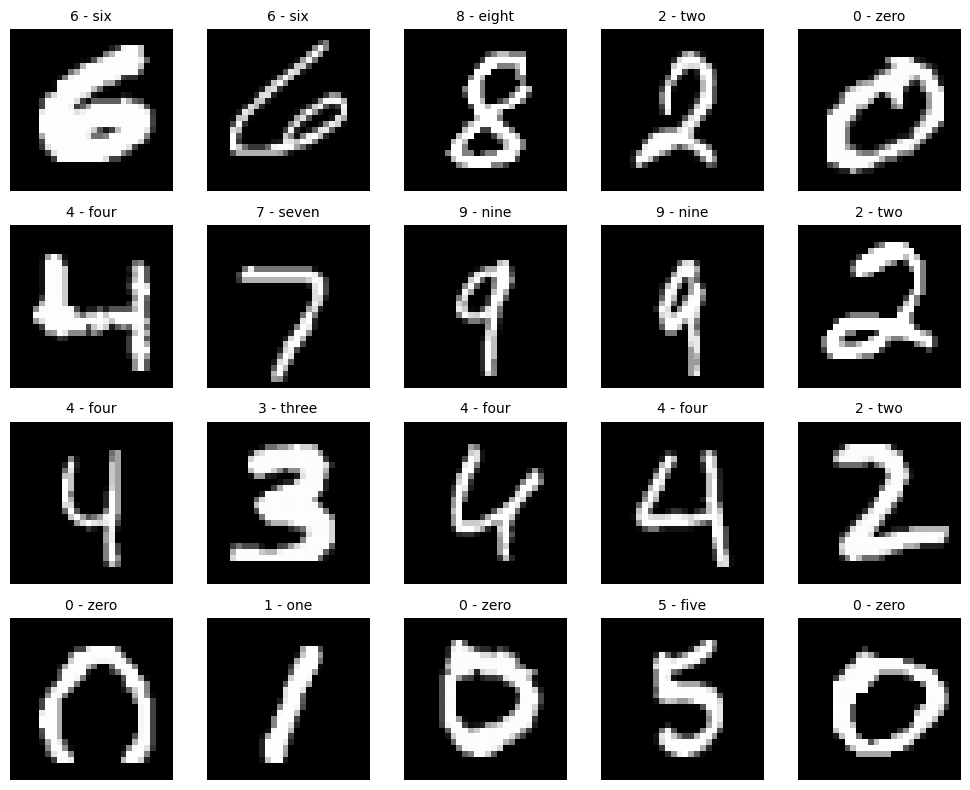

In [11]:
import torch
import matplotlib.pyplot as plt

# Reproducible results
torch.manual_seed(42)

rows, cols = 4, 5

fig = plt.figure(figsize=(10, 8))

for i in range(rows * cols):
    # Random image index
    idx = torch.randint(0, len(train_data), size=(1,)).item()

    image, label = train_data[idx]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(train_data.classes[label], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train dataloader batches: {len(train_dataloader)}")
print(f"Test dataloader batches: {len(test_dataloader)}")

Train dataloader batches: 1875
Test dataloader batches: 313


In [13]:
# Get one batch
train_features_batch, train_labels_batch = next(iter(train_dataloader))

print(f"Images batch shape: {train_features_batch.shape}")
print(f"Labels batch shape: {train_labels_batch.shape}")

Images batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [14]:
from torch import nn
import torch

class MNISTModelV2(nn.Module):
    """
    TinyVGG-style CNN model for MNIST.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units * 7 * 7,
                out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)

model_2 = MNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=10
).to(device)

model_2

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [16]:
from timeit import default_timer as timer
from tqdm.auto import tqdm
import torch
from torch import nn

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device):
    train_loss = 0
    train_acc = 0

    model.to(device)
    model.train()

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        train_loss += loss.item()
        train_acc += accuracy_fn(
            y_true=y,
            y_pred=y_logits.argmax(dim=1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    return train_loss, train_acc


def test_step(model, data_loader, loss_fn, accuracy_fn, device):
    test_loss = 0
    test_acc = 0

    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            test_logits = model(X)
            test_loss += loss_fn(test_logits, y).item()
            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_logits.argmax(dim=1)
            )

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    return test_loss, test_acc


def train_model(device, epochs=5):
    torch.manual_seed(42)

    model = MNISTModelV2(
        input_shape=1,
        hidden_units=10,
        output_shape=10
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=0.1
    )

    start_time = timer()

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            data_loader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
        )

        print(
            f"Epoch: {epoch + 1} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.2f}% | "
            f"Test loss: {test_loss:.4f} | "
            f"Test acc: {test_acc:.2f}%"
        )

    end_time = timer()
    total_time = end_time - start_time

    print(f"\nTotal training time on {device}: {total_time:.3f} seconds")

    return model, total_time

In [17]:
cpu_model, cpu_train_time = train_model(device="cpu")

 20%|██        | 1/5 [00:23<01:34, 23.52s/it]

Epoch: 1 | Train loss: 0.2648 | Train acc: 91.32% | Test loss: 0.0757 | Test acc: 97.65%


 40%|████      | 2/5 [00:46<01:09, 23.22s/it]

Epoch: 2 | Train loss: 0.0695 | Train acc: 97.80% | Test loss: 0.0439 | Test acc: 98.53%


 60%|██████    | 3/5 [01:11<00:47, 23.87s/it]

Epoch: 3 | Train loss: 0.0551 | Train acc: 98.30% | Test loss: 0.0480 | Test acc: 98.45%


 80%|████████  | 4/5 [01:34<00:23, 23.64s/it]

Epoch: 4 | Train loss: 0.0453 | Train acc: 98.56% | Test loss: 0.0437 | Test acc: 98.44%


100%|██████████| 5/5 [01:57<00:00, 23.55s/it]

Epoch: 5 | Train loss: 0.0404 | Train acc: 98.74% | Test loss: 0.0355 | Test acc: 98.83%

Total training time on cpu: 117.739 seconds


In [18]:
if torch.cuda.is_available():
    gpu_model, gpu_train_time = train_model(device="cuda")
else:
    print("CUDA GPU is not available in this environment.")

CUDA GPU is not available in this environment.


In [19]:
if torch.backends.mps.is_available():
    mps_model, mps_train_time = train_model(device="mps")
else:
    print("MPS is not available in this environment.")

 20%|██        | 1/5 [00:09<00:36,  9.22s/it]

Epoch: 1 | Train loss: 0.2672 | Train acc: 91.23% | Test loss: 0.0727 | Test acc: 97.66%


 40%|████      | 2/5 [00:18<00:27,  9.06s/it]

Epoch: 2 | Train loss: 0.0689 | Train acc: 97.81% | Test loss: 0.0417 | Test acc: 98.57%


 60%|██████    | 3/5 [00:27<00:18,  9.13s/it]

Epoch: 3 | Train loss: 0.0549 | Train acc: 98.28% | Test loss: 0.0459 | Test acc: 98.54%


 80%|████████  | 4/5 [00:36<00:08,  8.96s/it]

Epoch: 4 | Train loss: 0.0462 | Train acc: 98.57% | Test loss: 0.0396 | Test acc: 98.66%


100%|██████████| 5/5 [00:44<00:00,  8.95s/it]

Epoch: 5 | Train loss: 0.0410 | Train acc: 98.68% | Test loss: 0.0374 | Test acc: 98.79%

Total training time on mps: 44.741 seconds


The model was trained for 5 epochs on both CPU and Apple Silicon MPS.

CPU training time: 117.739 seconds  
MPS training time: 44.741 seconds

In this experiment, MPS was about 2.6× faster than CPU:

117.739 / 44.741 ≈ 2.63

This shows that using hardware acceleration can significantly reduce training time, even for a relatively small CNN model trained on MNIST. However, the exact speedup depends on the hardware, model size, dataset size, and device transfer overhead.

## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

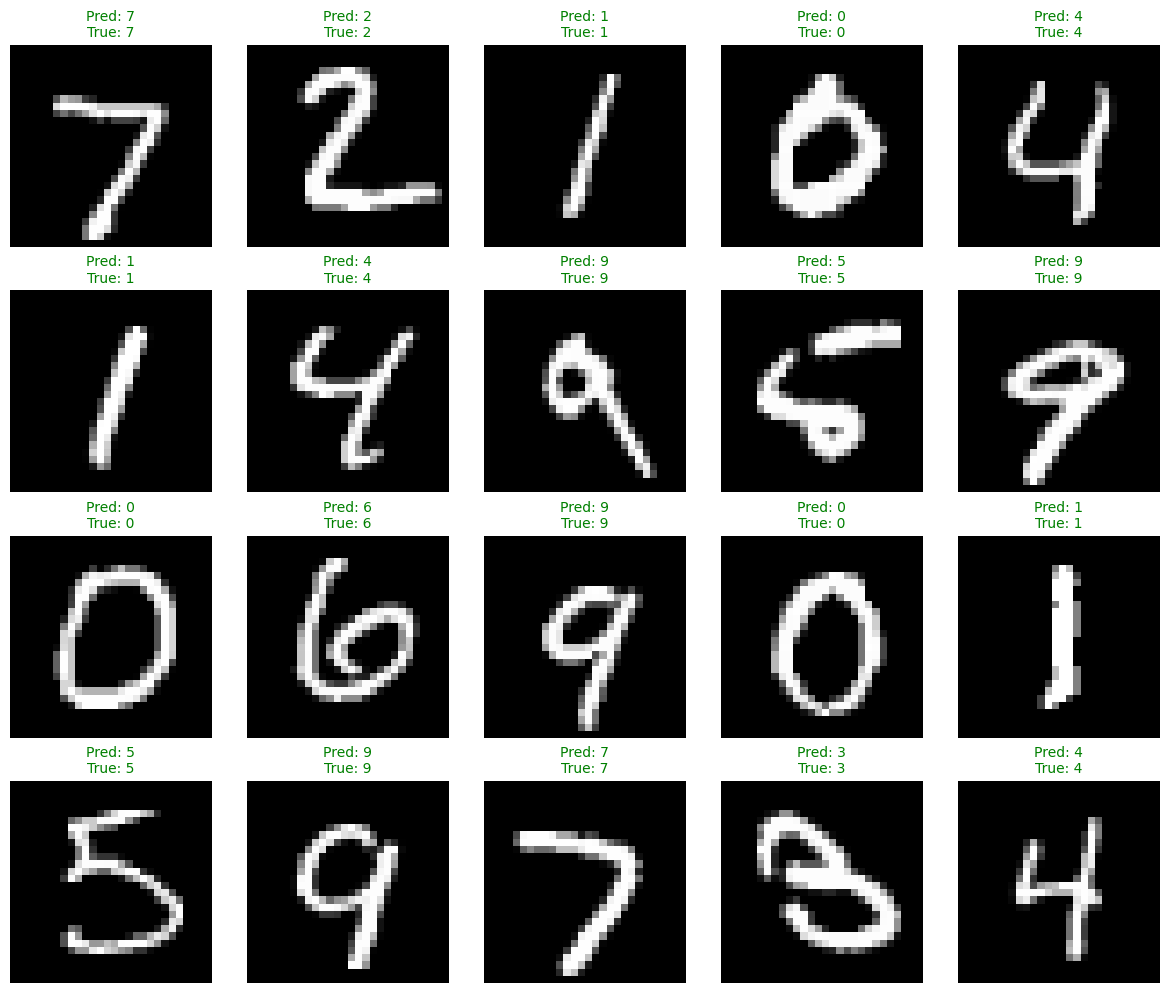

In [23]:
device = "mps"

# Set model to evaluation mode
mps_model.eval()

# Get one batch from the test DataLoader
images, labels = next(iter(test_dataloader))

# Move images to the target device
images = images.to(device)

# Make predictions
with torch.inference_mode():
    logits = mps_model(images)
    preds = torch.argmax(logits, dim=1)

# Move tensors back to CPU for visualization
images = images.cpu()
preds = preds.cpu()

# Display 20 images in a 4x5 grid
plt.figure(figsize=(12, 10))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    # Display image
    plt.imshow(images[i].squeeze(), cmap="gray")

    # Get prediction and ground truth
    pred_label = preds[i].item()
    true_label = labels[i].item()

    # Green title if correct, red if incorrect
    color = "green" if pred_label == true_label else "red"

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 490.90it/s]


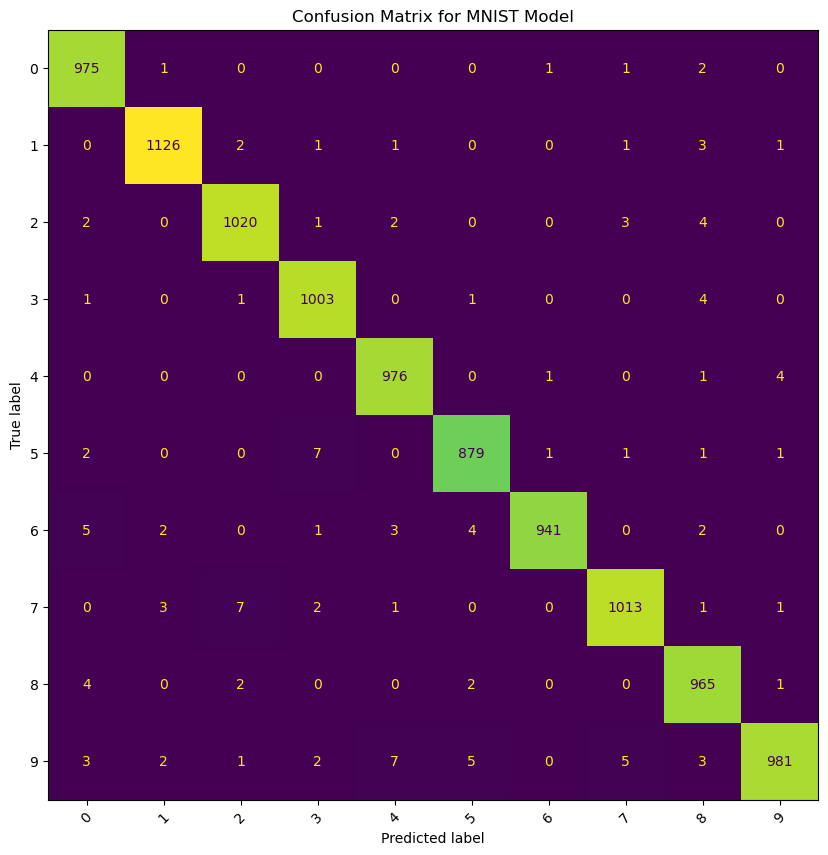

In [24]:
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

# Collect predictions
y_preds = []

mps_model.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X = X.to(device)

        logits = mps_model(X)
        preds = logits.argmax(dim=1)

        y_preds.append(preds.cpu())

# Combine all predictions into one tensor
y_pred_tensor = torch.cat(y_preds)

# Create confusion matrix
confmat = confusion_matrix(
    y_true=test_data.targets,
    y_pred=y_pred_tensor
)

# Plot confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=confmat,
    display_labels=[str(i) for i in range(10)]
)

fig, ax = plt.subplots(figsize=(10, 10))

display.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title("Confusion Matrix for MNIST Model")
plt.show()

The confusion matrix shows strong performance because the largest values are located on the main diagonal. This means the model usually predicts the correct digit.

Some small mistakes still appear outside the diagonal. For example, the model sometimes confuses:

- digit 5 with digit 3: 7 cases
- digit 7 with digit 2: 7 cases
- digit 9 with digit 4: 7 cases
- digit 9 with digit 7: 5 cases
- digit 6 with digit 0: 5 cases

These mistakes are understandable because some handwritten digits can look visually similar depending on writing style.

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

In [26]:
wrong_predictions = []

mps_model.eval()

with torch.inference_mode():
    for image, label in test_data:
        # Add batch dimension and move image to device
        image_batch = image.unsqueeze(dim=0).to(device)

        # Make prediction
        logits = mps_model(image_batch)
        pred_label = logits.argmax(dim=1).item()

        # Store only incorrect predictions
        if pred_label != label:
            wrong_predictions.append((image, pred_label, label))

        # Stop after collecting 9 wrong predictions
        if len(wrong_predictions) == 9:
            break

print(f"Collected {len(wrong_predictions)} wrong predictions.")

Collected 9 wrong predictions.


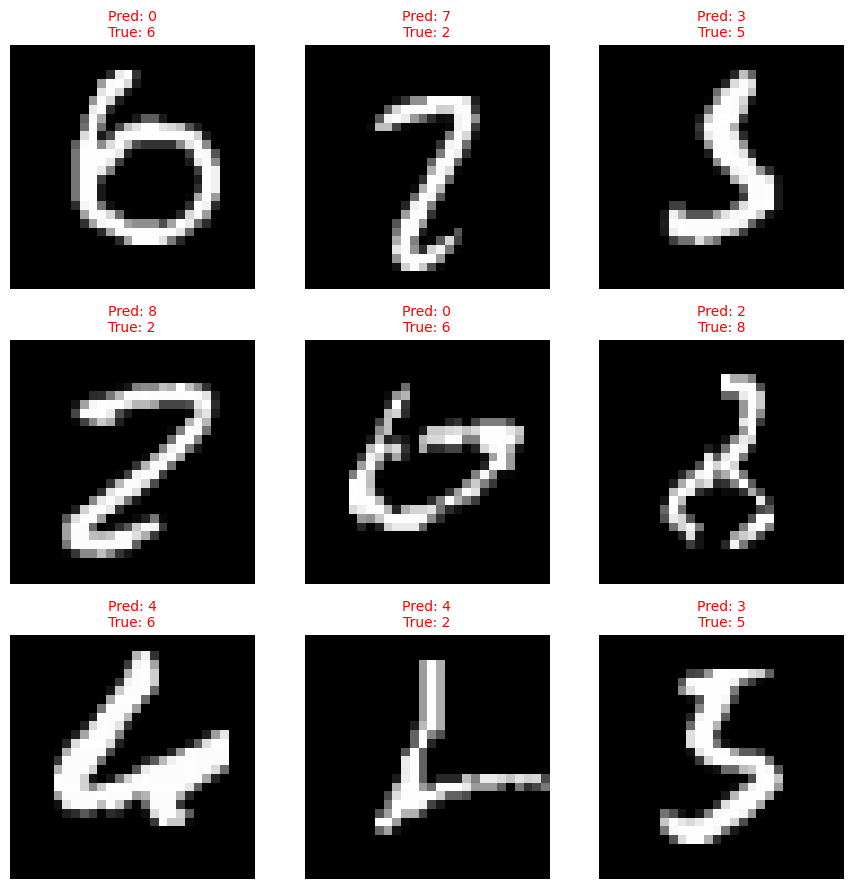

In [27]:
plt.figure(figsize=(9, 9))

for i, (image, pred_label, true_label) in enumerate(wrong_predictions):
    plt.subplot(3, 3, i + 1)

    plt.imshow(image.squeeze().numpy(), cmap="gray")

    plt.title(
        f"Pred: {pred_label}\nTrue: {true_label}",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

The model's wrong predictions often happen on ambiguous handwritten digits. Some examples are difficult even for a human to classify confidently because the writing style makes one digit look similar to another.

Therefore, the mistakes are likely caused by both factors:

1. Model limitations — the model could still improve with more training, better architecture, or data augmentation.
2. Data ambiguity — some handwritten digits are genuinely unclear or visually similar to other digits.

Overall, many mistakes are understandable because MNIST contains real handwritten digits with different writing styles.

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [28]:
import torch
from torch import nn

# Random input tensor
x = torch.randn(1, 3, 64, 64)

print(f"Input shape: {x.shape}\n")

# Example 1: kernel_size=3
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0
)

out1 = conv1(x)
print(f"kernel_size=3, stride=1, padding=0 -> {out1.shape}")

# Example 2: kernel_size=5
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=5,
    stride=1,
    padding=0
)

out2 = conv2(x)
print(f"kernel_size=5, stride=1, padding=0 -> {out2.shape}")

# Example 3: kernel_size=7
conv3 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=7,
    stride=1,
    padding=0
)

out3 = conv3(x)
print(f"kernel_size=7, stride=1, padding=0 -> {out3.shape}")

Input shape: torch.Size([1, 3, 64, 64])

kernel_size=3, stride=1, padding=0 -> torch.Size([1, 10, 62, 62])
kernel_size=5, stride=1, padding=0 -> torch.Size([1, 10, 60, 60])
kernel_size=7, stride=1, padding=0 -> torch.Size([1, 10, 58, 58])


Increasing `kernel_size` reduces the spatial dimensions of the output feature map (when no padding is used) and increases the number of parameters and computations.

For example:
- `kernel_size=3` → output shape `[1, 10, 62, 62]`
- `kernel_size=5` → output shape `[1, 10, 60, 60]`
- `kernel_size=7` → output shape `[1, 10, 58, 58]`

Smaller kernels are better at capturing local details and require fewer parameters, while larger kernels can see a larger portion of the image at once but are more computationally expensive.

This is one of the reasons why modern CNN architectures commonly use small kernels (such as 3×3) stacked in multiple layers instead of a single large kernel.